# Titanic Survival Prediction

In [1]:
import pandas as pd
import numpy as np

# modules for visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression # Logistic Regression can be used both for Classification and Regression problems
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

## Load Data

In [2]:
df = sns.load_dataset("titanic")
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Selecting Feature

In [5]:
features = ["pclass", "sex", "age", "fare", "embarked"]
target = "survived"

df = df[features + [target]]

In [6]:
df.head()

,pclass,sex,age,fare,embarked,survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


## Hadling Missing Value
As we can see from the df evaluation, there are quite some data missing. This section will work out the way we use to tackle those missing number

In [7]:
df["age"].fillna(df["age"].median(), inplace=True)
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

C:\Users\nguye\AppData\Local\Temp\ipykernel_28136\2526786661.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
C:\Users\nguye\AppData\Local\Temp\ipykernel_28136\2526786661.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [8]:
df.isnull().sum()

pclass      0
sex         0
age         0
fare        0
embarked    0
survived    0
dtype: int64

we have fix this problem by adding data into the missing value. In this case, we choosed to use median for filling info

### Splitting data

In [9]:
X = df.drop("survived", axis=1)
y = df.survived

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

### Preprocessing Data

In [10]:
from sklearn.preprocessing import OneHotEncoder


num_cols = ["age", "fare"]
cat_cols = ["pclass", "sex", "embarked"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [11]:
## Build Pipeline after having the model and the preprocessing 

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [12]:
## creating evaluation function

from sklearn.metrics import f1_score


def evaluation(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

In [13]:
log_results = evaluation(
    "Logistic Regression",
    y_test,
    y_pred_log
)

Model: Logistic Regression
Accuracy:  0.7877
Precision: 0.7571
Recall:    0.7162
F1 Score:  0.7361
------------------------------


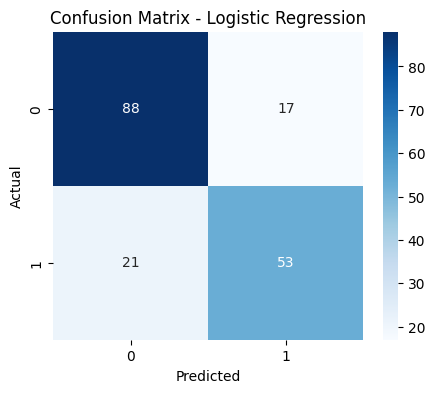

In [14]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Tree model

In [15]:
tree_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

tree_results = evaluation(
    "Decision tree",
    y_test,
    y_pred_tree
)

Model: Decision tree
Accuracy:  0.7989
Precision: 0.8276
Recall:    0.6486
F1 Score:  0.7273
------------------------------


## Random Forrest

In [16]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_results = evaluation(
    "Random Forest",
    y_test,
    y_pred_rf
)

Model: Random Forest
Accuracy:  0.7821
Precision: 0.7273
Recall:    0.7568
F1 Score:  0.7417
------------------------------


## Compare Models

In [17]:
results_df = pd.DataFrame(
    log_results,
    tree_results,
    rf_results
)

results_df

,Model,Accuracy,Precision,Recall,F1
Model,Logistic Regression,0.787709,0.757143,0.716216,0.736111
Accuracy,Logistic Regression,0.787709,0.757143,0.716216,0.736111
Precision,Logistic Regression,0.787709,0.757143,0.716216,0.736111
Recall,Logistic Regression,0.787709,0.757143,0.716216,0.736111
F1,Logistic Regression,0.787709,0.757143,0.716216,0.736111


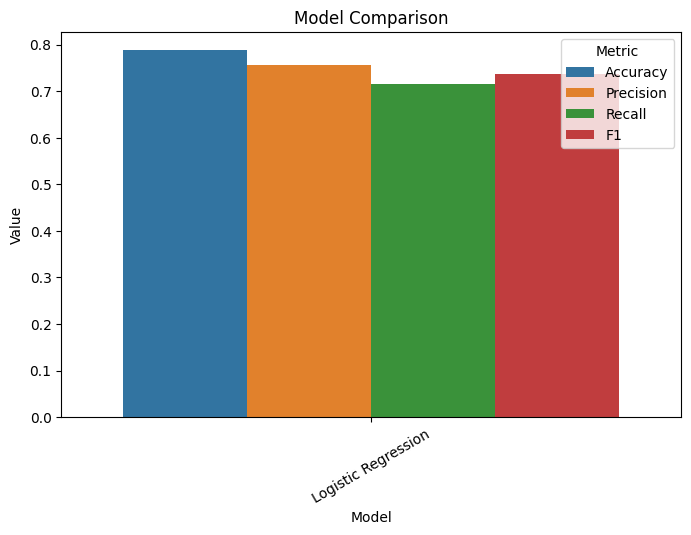

In [18]:
results_melted = results_df.melt(
    id_vars= "Model",
    var_name= "Metric",
    value_name= "Value"
)

plt.figure(figsize=(8,5))
sns.barplot(data= results_melted, x="Model", y="Value", hue= "Metric")
plt.title("Model Comparison")
plt.xticks(rotation= 30)
plt.show()